In [2]:
from firedrake import *
from cell_problem import CellProblem
from homogenization_problem import HomogenizationProblem
from geometry import *
from effective_problem import *

In [9]:
n = 70
data = {
    "R": 5,
    "t": 2.5,
    "l": 25
}
mu_fun = lambda x,y,z: conditional(inside_dark(x,y,z, data), Constant(0.1), Constant(100))
lmbda_fun = lambda x,y,z: conditional(inside_dark(x,y,z, data), Constant(0.0), Constant(0.0))

In [10]:
# SOLVE THE LOCAL PERIODIC PROBLEM AND COMPUTE EFFECTIVE COEFFICIENTS
cell_pb = CellProblem(n, mu_fun, lmbda_fun)
homogenization_pb = HomogenizationProblem(cell_pb, 2)
Ceff, tCeff, Ceff_np, tCeff_np = homogenization_pb.run()


ORDER 2:
  multi-index = (0,0)


ConvergenceError: Nonlinear solve failed to converge after 0 nonlinear iterations.
Reason:
   DIVERGED_LINEAR_SOLVE

In [5]:
import matplotlib.pyplot as plt

def check_effective_tensors(
        Ceff0,
        tCeff0,
        CST=None,
        cst=None,
        mesh=None,
        verbose=True,
        plot=False):
    """
    Post-process homogenized fourth-order tensors.

    Parameters
    ----------
    Ceff0 : ndarray
        Effective elasticity tensor C^0_eff, shape (3,3,3,3).

    tCeff0 : ndarray
        Effective tilde tensor, shape (3,3,3,3).

    CST : optional
        Reference isotropic tensor. Can be numpy or UFL/Firedrake tensor.

    cst : optional
        Local elasticity tensor (UFL/Firedrake).
        Used only if its average is requested.

    mesh : optional
        Needed if cst is a Firedrake expression.

    Returns
    -------
    dict
        Dictionary containing errors, Voigt matrices, effective Lamé
        parameters, anisotropy measures.
    """

    results = {}


    # ------------------------------------------------------
    # Convert effective tensors
    # ------------------------------------------------------

    Ceff0 = np.asarray(Ceff0)
    tCeff0 = np.asarray(tCeff0)

    # if Ceff0.shape != (3,3,3,3):
    #     raise ValueError(
    #         f"Ceff0 must be a fourth order tensor "
    #         f"with shape (3,3,3,3), got {Ceff0.shape}"
    #     )
    # if tCeff0.shape != (3,3,3,3):
    #     raise ValueError(
    #         f"tCeff0 must be a fourth order tensor "
    #         f"with shape (3,3,3,3), got {tCeff0.shape}"
    #     )


    # ------------------------------------------------------
    # Voigt conversion
    # ------------------------------------------------------

    def tensor_to_voigt(C):

        pairs = [
            (0,0),
            (1,1),
            (2,2),
            (1,2),
            (0,2),
            (0,1)
        ]

        V = np.zeros((6,6))

        for I,(i,j) in enumerate(pairs):
            for J,(k,l) in enumerate(pairs):
                V[I,J] = C[i,j,k,l]

        return V


    Ceff_voigt = tensor_to_voigt(Ceff0)

    results["Ceff_voigt"] = Ceff_voigt


    # ------------------------------------------------------
    # Compare with CST
    # ------------------------------------------------------

    if CST is not None:

        try:
            CST_np = np.asarray(CST)

        except Exception:
            raise TypeError(
                "CST is not a numpy tensor. "
                "Evaluate it before calling this function."
            )


        Delta = Ceff0 - CST_np

        err = np.linalg.norm(Delta)/np.linalg.norm(CST_np)

        results["relative_error_Ceff_CST"] = err
        results["Delta_voigt"] = tensor_to_voigt(Delta)


        if verbose:
            print("\nComparison with CST")
            print("-------------------")
            print(
                "||Ceff-CST||/||CST|| = ",
                err
            )


    # ------------------------------------------------------
    # Isotropic projection
    # ------------------------------------------------------

    lambda_eff = (
        Ceff0[0,0,1,1]
        +
        Ceff0[0,0,2,2]
        +
        Ceff0[1,1,2,2]
    )/3


    mu_eff = (
        Ceff0[0,1,0,1]
        +
        Ceff0[0,2,0,2]
        +
        Ceff0[1,2,1,2]
    )/3


    results["lambda_eff"] = lambda_eff
    results["mu_eff"] = mu_eff


    delta = np.eye(3)

    Ciso = np.zeros((3,3,3,3))

    for i in range(3):
        for j in range(3):
            for k in range(3):
                for l in range(3):

                    Ciso[i,j,k,l] = (
                        mu_eff*delta[i,k]*delta[j,l]
                        +
                        lambda_eff*delta[i,j]*delta[k,l]
                    )


    anisotropy = (
        np.linalg.norm(Ceff0-Ciso)
        /
        np.linalg.norm(Ceff0)
    )

    results["anisotropy"] = anisotropy


    if verbose:

        print("\nEffective isotropic parameters")
        print("--------------------------------")
        print("lambda_eff =", lambda_eff)
        print("mu_eff     =", mu_eff)

        print("\nAnisotropy")
        print("--------------------------------")
        print(
            "||Ceff-Ciso||/||Ceff|| = ",
            anisotropy
        )


    # ------------------------------------------------------
    # Visualization
    # ------------------------------------------------------

    if plot:

        plt.figure(figsize=(5,4))
        plt.imshow(
            Ceff_voigt,
            interpolation="nearest"
        )
        plt.colorbar()
        plt.title("Ceff Voigt matrix")
        plt.show()


        if CST is not None:

            plt.figure(figsize=(5,4))
            plt.imshow(
                tensor_to_voigt(Ceff0-CST_np),
                interpolation="nearest"
            )
            plt.colorbar()
            plt.title("Ceff-CST")
            plt.show()

            
        if CST is not None:

            plt.figure(figsize=(5,4))
            plt.imshow(
                tensor_to_voigt(CST_np),
                interpolation="nearest"
            )
            plt.colorbar()
            plt.title("CST")
            plt.show()

    return results


Comparison with CST
-------------------
||Ceff-CST||/||CST|| =  0.7071067811865476

Effective isotropic parameters
--------------------------------
lambda_eff = -7.22468359043277e-35
mu_eff     = 0.2499999999999999

Anisotropy
--------------------------------
||Ceff-Ciso||/||Ceff|| =  0.7071067811865477


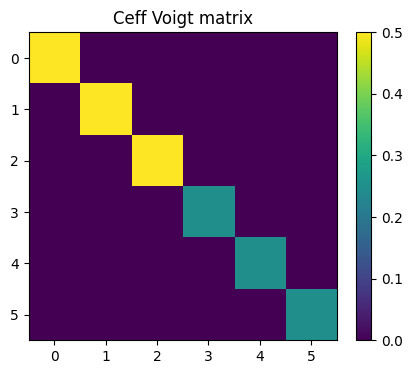

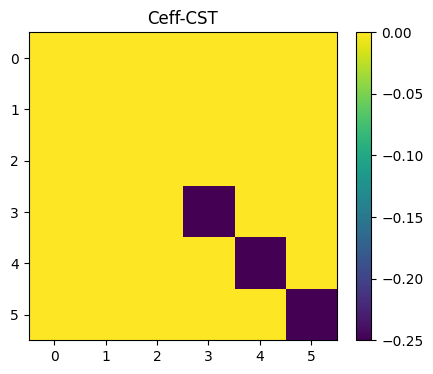

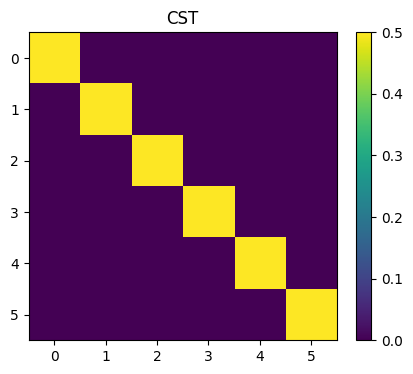

In [6]:
results = check_effective_tensors(
    Ceff_np,
    tCeff_np,
    CST=cell_pb.CST_np,
    verbose=True,
    plot=True
)